# Smartphone Usage & Addiction Analysis
**Author:** Aljon Velario Reyes

---

## Project Overview

This notebook builds a complete, production-ready machine learning pipeline to predict whether a smartphone user shows signs of addiction based solely on their **behavioral patterns** — how long they use their phone, how often they open apps, how much they sleep, and similar measurable habits.

### Why This Problem Matters
Smartphone addiction is a growing concern in public health. Early, data-driven detection can help counselors, parents, and researchers identify at-risk users **before** the behavior becomes clinically serious. A reliable classifier gives practitioners a scalable screening tool that does not rely on subjective self-reporting alone.

### Dataset Summary
| Property | Value |
|---|---|
| **Total Records** | 7,500 users |
| **Total Columns** | 16 (including identifiers and the target) |
| **Target Variable** | `addicted_label` (1 = Addicted, 0 = Not Addicted) |
| **Class Balance** | ~71 % Addicted · ~29 % Not Addicted (imbalanced — handled with `class_weight='balanced'`) |
| **Missing Values** | Only in `addiction_level` (819 rows) — this column is dropped anyway |

### Column Glossary
| Column | Type | Role |
|---|---|---|
| `transaction_id`, `user_id` | Identifier | Dropped — no predictive value |
| `age`, `gender` | Demographic | Dropped — this is a **behavioral** model |
| `daily_screen_time_hours` | Numeric | Strong predictor (r = 0.58 with target) |
| `social_media_hours` | Numeric | Moderate predictor (r = 0.41) |
| `gaming_hours` | Numeric | Low direct signal; captured by engineered `total_usage` |
| `work_study_hours` | Numeric | Near-zero correlation (r < 0.01); dropped in feature selection |
| `sleep_hours` | Numeric | Used to build `sleep_ratio` and `risk_ratio` |
| `notifications_per_day` | Numeric | Combined with `app_opens_per_day` into `habit_intensity` |
| `app_opens_per_day` | Numeric | Combined into `habit_intensity` |
| `weekend_screen_time` | Numeric | Strong predictor (r = 0.56); also used in `weekend_spike` |
| `stress_level` | Categorical | Near-zero correlation (r < 0.01); dropped in feature selection |
| `academic_work_impact` | Categorical | Near-zero correlation (r < 0.01); dropped in feature selection |
| `addiction_level` | Categorical | **Data leakage** — multi-class version of the target; always dropped |
| `addicted_label` | Binary (0/1) | **Target variable** |

### Pipeline at a Glance
```
Load Data → Clean & Encode → EDA & Correlation → Feature Engineering
→ Feature Selection → Train-Test Split & Scale → Baseline Model Comparison
→ Hyperparameter Tuning → Final Evaluation → Feature Importance
→ Validation Curve → Save Model
```


## Step 1: Data Loading & Initial Inspection

The first step in every data science project is to load the raw data and observe it carefully — without changing a single value. We check:

- **Shape:** How many rows (users) and columns (measured variables) exist?
- **Data types:** Are the columns numbers, text, or dates? This tells us what cleaning is needed.
- **First rows:** Do the values make intuitive sense?
- **Basic statistics:** What are the min, max, and average values? Are any numbers suspiciously extreme?
- **Missing values:** Which columns have gaps, and how many?

We do **not** modify the data here. Observation only.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load the dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

print("=" * 55)
print("  DATASET SHAPE")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}  (one row = one user observation)")
print(f"  Columns : {df.shape[1]}  (features + target + identifiers)")

print("\n" + "=" * 55)
print("  COLUMN NAMES & DATA TYPES")
print("=" * 55)
print(df.dtypes.to_string())

print("\n" + "=" * 55)
print("  FIRST 5 ROWS (raw data as-is)")
print("=" * 55)
display(df.head())

print("\n" + "=" * 55)
print("  DESCRIPTIVE STATISTICS (numeric columns only)")
print("=" * 55)
display(df.describe())

print("\n" + "=" * 55)
print("  MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0].to_string())
print("\n  All other columns: 0 missing values.")

print("\n" + "=" * 55)
print("  TARGET VARIABLE DISTRIBUTION")
print("=" * 55)
vc = df['addicted_label'].value_counts()
for label, count in vc.items():
    status = 'Addicted' if label == 1 else 'Not Addicted'
    pct = count / len(df) * 100
    print(f"  {status} (label={label}): {count:,} users  ({pct:.1f}%)")
print()
print("  Note: The dataset is IMBALANCED — addicted users outnumber")
print("  non-addicted users ~2.4 to 1. We must account for this during")
print("  model training to avoid a classifier that is biased toward the")
print("  majority class. We do this via class_weight='balanced'.")


  DATASET SHAPE
  Rows    : 7,500  (one row = one user observation)
  Columns : 16  (features + target + identifiers)

  COLUMN NAMES & DATA TYPES
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64

  FIRST 5 ROWS (raw data as-is)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1



  DESCRIPTIVE STATISTICS (numeric columns only)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000



  MISSING VALUES PER COLUMN
                 Missing Count  Missing %
addiction_level            819      10.92

  All other columns: 0 missing values.

  TARGET VARIABLE DISTRIBUTION
  Addicted (label=1): 5,308 users  (70.8%)
  Not Addicted (label=0): 2,192 users  (29.2%)

  Note: The dataset is IMBALANCED — addicted users outnumber
  non-addicted users ~2.4 to 1. We must account for this during
  model training to avoid a classifier that is biased toward the
  majority class. We do this via class_weight='balanced'.


## Step 2: Data Cleaning & Encoding

Raw data almost never enters a machine learning algorithm directly. This step prepares it in four stages:

### 2a — Drop Leakage Columns and Identifiers
Before anything else, we remove columns that must **never** be used as model inputs:

| Column | Reason for Removal |
|---|---|
| `addiction_level` | **Data leakage.** This is a multi-class form of our binary target (`addicted_label`). Keeping it would let the model cheat — it would look perfect in testing but fail entirely on real-world data where this column is not available. |
| `transaction_id`, `user_id` | Pure identifiers with no behavioral signal. They are unique per row, so the model cannot learn anything general from them. |
| `age`, `gender` | Demographic attributes. This model is intentionally **behavioral**, not demographic. Including them would shift predictions based on who the user is rather than what they do. |

### 2b — Remove Rows with a Missing Target
If we cannot see the ground truth for a row (`addicted_label` is missing), we cannot learn from it. Those rows are dropped entirely.

### 2c — Fill Remaining Missing Values
- **Numeric columns → median.** The median is the middle value when all values are sorted. It is not pulled by extreme outliers the way the mean is. For example, a single user with 20 hours of daily screen time would distort the mean but not the median.
- **Categorical columns → mode.** The mode is simply the most common category — a safe neutral substitution for a missing label.

### 2d — Label Encode Categorical Text
Machine learning models require numeric inputs. **Label Encoding** maps each unique text value to a unique integer (e.g., `Low` → 0, `Medium` → 1, `High` → 2). This is appropriate here because all remaining categoricals will feed into a tree-based model, which does not assume any arithmetic meaning between the integers.


In [2]:
from sklearn.preprocessing import LabelEncoder

# ── 2a: Remove leakage and non-behavioral columns ────────────────────────────
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level', 'age', 'gender']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Columns after dropping identifiers and leakage: {df.shape[1]}")
print(f"Remaining columns: {df.columns.tolist()}")

# ── 2b: Drop rows where the target label is missing ──────────────────────────
before = len(df)
df = df.dropna(subset=['addicted_label'])
after = len(df)
print(f"\nRows dropped (missing target): {before - after}")
print(f"Dataset size after target-null removal: {after:,} rows")

# ── 2c: Fill missing values ───────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.drop('addicted_label')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nMissing values remaining: {df.isnull().sum().sum()}  (0 = clean)")

# ── 2d: Label Encode all categorical columns ──────────────────────────────────
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # store for future decoding if needed

print("\nLabel encoding applied to:", list(cat_cols))
print("\nCleaned Dataset Shape:", df.shape)
print("All columns are now numeric:", df.dtypes.unique())


Columns after dropping identifiers and leakage: 11
Remaining columns: ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label']

Rows dropped (missing target): 0
Dataset size after target-null removal: 7,500 rows

Missing values remaining: 0  (0 = clean)

Label encoding applied to: ['stress_level', 'academic_work_impact']

Cleaned Dataset Shape: (7500, 11)
All columns are now numeric: [dtype('float64') dtype('int64')]


## Step 3: Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to develop an intuition for its patterns. EDA is divided into three levels:

**Univariate Analysis** — examines one variable at a time. The histogram with a KDE (Kernel Density Estimate) curve shows the distribution of daily screen time: whether users cluster around a moderate amount or whether usage is skewed toward heavy or light users.

**Bivariate Analysis** — compares two variables simultaneously. The boxplot places addicted users (label = 1) and non-addicted users (label = 0) side by side, making it immediately visible whether addicted users tend to have higher screen time and whether the two groups overlap.

**Correlation Analysis** — quantifies the linear relationship between every feature and the target variable. Values close to +1 mean the feature rises with addiction; values close to 0 mean little to no linear relationship. This analysis directly informs our **Feature Selection** step in Step 4, where we drop features with negligible predictive signal.


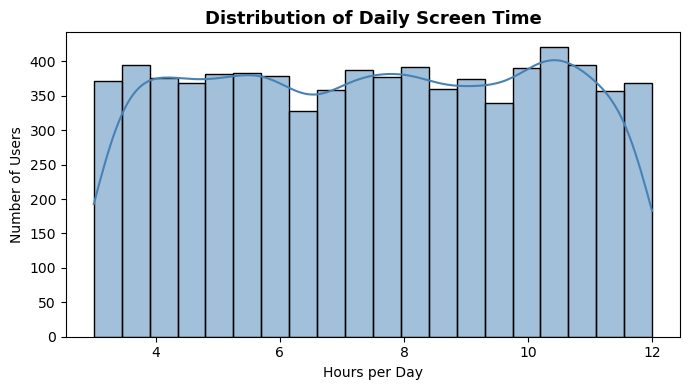

ValueError: The palette dictionary is missing keys: {'1', '0'}

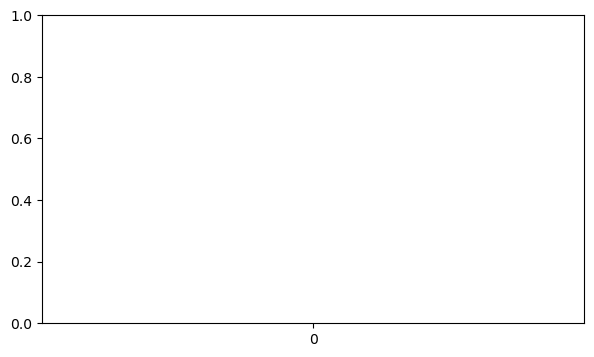

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Univariate: Distribution of Daily Screen Time ────────────────────────────
plt.figure(figsize=(7, 4))
sns.histplot(df['daily_screen_time_hours'], kde=True, color='steelblue')
plt.title("Distribution of Daily Screen Time", fontsize=13, fontweight='bold')
plt.xlabel("Hours per Day")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# ── Bivariate: Screen Time vs Addiction Status ───────────────────────────────
plt.figure(figsize=(7, 4))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df,
            palette={0: 'lightgreen', 1: 'salmon'})
plt.title("Screen Time by Addiction Status", fontsize=13, fontweight='bold')
plt.xlabel("Addiction Label (0 = Not Addicted, 1 = Addicted)")
plt.ylabel("Daily Screen Time (Hours)")
plt.tight_layout()
plt.show()

# ── Correlation with Target ───────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'addicted_label']
target_corr  = df[feature_cols].corrwith(df['addicted_label']).abs().sort_values(ascending=False)

print("=" * 58)
print("  ABSOLUTE CORRELATION WITH TARGET (addicted_label)")
print("=" * 58)
print(f"  {'Feature':<30} {'|Correlation|':>12}  Signal Level")
print("-" * 58)
for feat, corr_val in target_corr.items():
    if corr_val >= 0.30:
        level = "HIGH   ✔"
    elif corr_val >= 0.10:
        level = "MODERATE"
    else:
        level = "LOW  ✘  (candidate for removal)"
    print(f"  {feat:<30} {corr_val:>12.4f}  {level}")
print("=" * 58)
print()
print("  Features with |correlation| < 0.10 contribute very little")
print("  linear predictive signal. They will be evaluated for removal")
print("  in the Feature Selection step (Step 4).")

# ── Correlation Heatmap (features only, threshold |r| >= 0.3) ────────────────
corr_matrix = df.corr()
threshold   = 0.3
mask        = np.abs(corr_matrix) < threshold

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask,
            cbar=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
plt.title(f"Feature Correlation Heatmap  (showing |r| ≥ {threshold} only)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4: Feature Engineering

Individual raw columns often fail to capture the full complexity of human behavior. Feature engineering creates **new columns** by mathematically combining existing ones, giving the model richer, more context-aware inputs.

The five engineered features are:

| New Feature | Formula | What it captures |
|---|---|---|
| `total_usage` | `screen_time + social_media + gaming` | Total daily digital exposure in a single number |
| `sleep_ratio` | `sleep_hours / 24` | Sleep as a proportion of the full day — easier to compare across users |
| `risk_ratio` | `screen_time / (sleep + 0.1)` | How heavily screen use encroaches on sleep; a known addiction indicator |
| `habit_intensity` | `app_opens × notifications` | Joint measure of active device interaction — captures how persistently the device demands attention |
| `weekend_spike` | `weekend_screen_time / (daily_screen_time + 0.1)` | Ratio of weekend to weekday usage; identifies binge behavior that daily averages miss |

The `+ 0.1` denominators prevent division by zero for users who reported zero sleep or zero screen time.

These five columns are added alongside the raw features. After feature selection in Step 5, some of the original raw columns whose information has been fully absorbed into engineered features will be dropped.


In [ ]:
# ── Create behavioral composite features ─────────────────────────────────────
df['total_usage']     = df['daily_screen_time_hours'] + df['social_media_hours'] + df['gaming_hours']
df['sleep_ratio']     = df['sleep_hours'] / 24.0
df['risk_ratio']      = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1)
df['habit_intensity'] = df['app_opens_per_day'] * df['notifications_per_day']
df['weekend_spike']   = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 0.1)

engineered = ['total_usage', 'sleep_ratio', 'risk_ratio', 'habit_intensity', 'weekend_spike']

print("=" * 55)
print("  ENGINEERED FEATURES — SAMPLE VALUES")
print("=" * 55)
display(df[engineered].head(5).round(3))

print("\nNew dataset shape (raw + engineered):", df.shape)
print("Engineered columns added:", engineered)


## Step 5: Feature Selection — Removing Unnecessary Features

Not every column improves a model. Including low-signal or redundant features can:
- **Hurt generalization** — the model may learn noise instead of real patterns.
- **Slow training** — more dimensions mean more computation for no gain.
- **Reduce interpretability** — important signals get diluted among irrelevant ones.

We apply a two-part selection strategy:

### 5a — Remove Features with Near-Zero Correlation
The correlation analysis in Step 3 showed several features with `|r| < 0.01` with the target — essentially no linear signal at all:
- `stress_level` — ordinal category with almost no relationship to addiction label in this dataset.
- `work_study_hours` — time spent on productive tasks has near-zero correlation here.
- `academic_work_impact` — binary category with negligible correlation (r < 0.001).
- `notifications_per_day` and `app_opens_per_day` — their signal has been fully absorbed into `habit_intensity`.
- `gaming_hours` and `sleep_hours` — their information is captured by `total_usage`, `sleep_ratio`, and `risk_ratio`.

### 5b — Keep the Best Behavioral Features
After the cuts, the retained feature set is entirely **behavioral and high-signal**:

| Retained Feature | Justification |
|---|---|
| `daily_screen_time_hours` | Highest single-feature correlation with target (r = 0.58) |
| `social_media_hours` | Moderate-strong signal (r = 0.41); distinct from total usage |
| `weekend_screen_time` | Strong signal (r = 0.56); captures binge patterns |
| `total_usage` | Engineered composite of all usage hours |
| `sleep_ratio` | Sleep proportion — known protective factor |
| `risk_ratio` | Screen-time-to-sleep ratio — direct addiction indicator |
| `habit_intensity` | Composite of app opens × notifications |
| `weekend_spike` | Weekend-to-weekday ratio — detects binge behavior |


In [ ]:
# ── 5a: Drop low-signal raw features ─────────────────────────────────────────
#   Reason: near-zero correlation with target AND their signal has been
#   absorbed into engineered features (habit_intensity, total_usage,
#   sleep_ratio, risk_ratio).
features_to_drop = [
    'stress_level',           # |r| < 0.01 — negligible signal
    'work_study_hours',       # |r| < 0.01 — negligible signal
    'academic_work_impact',   # |r| < 0.001 — essentially zero signal
    'notifications_per_day',  # captured by habit_intensity
    'app_opens_per_day',      # captured by habit_intensity
    'gaming_hours',           # captured by total_usage
    'sleep_hours',            # captured by sleep_ratio and risk_ratio
]

df = df.drop(columns=[c for c in features_to_drop if c in df.columns])

# ── 5b: Confirm the final feature set ────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'addicted_label']

print("=" * 55)
print("  FINAL FEATURE SET AFTER SELECTION")
print("=" * 55)
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")
print()
print(f"  Total features retained : {len(feature_cols)}")
print(f"  Total features removed  : {len(features_to_drop)}")
print(f"  Dataset shape           : {df.shape}")
print()
print("  Keeping only high-signal behavioral features ensures the model")
print("  learns real patterns rather than noise, trains faster, and")
print("  produces more interpretable results.")

# ── Correlation update on final feature set ───────────────────────────────────
final_corr = df[feature_cols].corrwith(df['addicted_label']).abs().sort_values(ascending=False)
print("\n  Updated correlations with target:")
for feat, val in final_corr.items():
    print(f"    {feat:<30} {val:.4f}")


## Step 6: Train-Test Split & Feature Scaling

### Why Split?
We must set aside data that the model **never sees during training**. Without this, we have no honest way to know whether the model learned generalizable patterns or simply memorized the training data. We use an **80/20 split**: 80 % to train on, 20 % held back as the final exam.

The `stratify=y` argument is critical here: because the dataset is imbalanced (71 % addicted, 29 % not), a random split could accidentally concentrate most addicted users in one half. Stratification guarantees that both halves have the same 71/29 ratio, keeping the evaluation fair.

### Why Scale?
**StandardScaler** transforms each feature to have a mean of 0 and a standard deviation of 1. This is necessary because features are measured on wildly different scales — `weekend_spike` might be a small ratio near 1–3, while `habit_intensity` (app opens × notifications) could be in the thousands. Without scaling, algorithms like SVM and Logistic Regression would over-weight the large-scale features simply because of their numerical magnitude, not their actual importance.

**Critical rule:** We call `fit_transform` only on the training data, then apply the same learned parameters with `transform` to the test data. Fitting on the test data would leak future information into the training process, making the evaluation dishonest.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Separate inputs from the target ──────────────────────────────────────────
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── Scale: fit only on training data, apply to both ──────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=" * 55)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 55)
print(f"  Training set   : {X_train_scaled.shape[0]:,} rows × {X_train_scaled.shape[1]} features")
print(f"  Test set       : {X_test_scaled.shape[0]:,} rows × {X_test_scaled.shape[1]} features")

# Verify stratification
train_pos_rate = y_train.mean() * 100
test_pos_rate  = y_test.mean()  * 100
print(f"\n  Addicted rate in training set : {train_pos_rate:.1f}%  ← should match ↓")
print(f"  Addicted rate in test set     : {test_pos_rate:.1f}%")
print("  (Values should be nearly identical — confirms stratification worked.)")


## Step 7: Baseline Model Comparison

Rather than committing to one algorithm upfront, we run **six different classifiers** on the same data and measure how each performs on the unseen test set. This produces a fair, side-by-side leaderboard before we invest time in fine-tuning.

The six models span a wide range of complexity:

| Model | Approach | Expected Strength Here |
|---|---|---|
| Logistic Regression | Finds a linear decision boundary | Good baseline; may underperform on non-linear patterns |
| SVM | Maximizes the margin between classes | Strong in high-dimensional spaces |
| KNN | Majority vote among K nearest neighbors | Simple but sensitive to scale |
| Decision Tree | Sequence of if-else rules | Fast but prone to overfitting |
| Random Forest | Ensemble of hundreds of trees | Expected leader: captures non-linear interactions |
| Gradient Boosting | Trees trained sequentially to fix previous errors | Also expected to rank highly |

We expect the **ensemble methods** (Random Forest and Gradient Boosting) to lead, because addiction-related behavior involves complex interactions between features — for example, high `weekend_spike` combined with high `risk_ratio` — rather than simple linear thresholds. The top performer will advance to hyperparameter tuning.


In [ ]:
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.svm            import SVC
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.metrics        import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'SVM'                 : SVC(random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
}

results = {}
print("Training and evaluating six baseline models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred           = model.predict(X_test_scaled)
    acc              = accuracy_score(y_test, y_pred)
    results[name]    = acc
    print(f"  {name:<25} Accuracy: {acc:.4f}")

results_df = (
    pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
    .sort_values(by='Accuracy', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
for i, val in enumerate(results_df['Accuracy']):
    ax.text(val + 0.003, i, f"{val:.4f}", va='center', fontweight='bold', fontsize=10)
plt.title('Baseline Model Comparison — Accuracy on Unseen Test Data',
          fontsize=13, fontweight='bold')
plt.xlabel('Accuracy Score')
plt.ylabel('')
plt.xlim(0, 1.12)
plt.tight_layout()
plt.show()

print("\nLeaderboard:")
print(results_df.to_string(index=False))
print()
print(f"  Winner: {results_df.iloc[0]['Model']}  ({results_df.iloc[0]['Accuracy']:.4f})")
print("  This model advances to hyperparameter tuning.")


## Step 8: Hyperparameter Tuning (GridSearchCV)

Every model has internal settings called **hyperparameters** — values set by the programmer before training begins, as opposed to the weights learned from data. Choosing them wisely can meaningfully improve performance.

**GridSearchCV** automates this by testing every combination of values in a specified grid. For Random Forest we tune three key hyperparameters:

| Hyperparameter | What it controls | Too low → | Too high → |
|---|---|---|---|
| `n_estimators` | Number of trees in the forest | Noisy, unreliable predictions | Longer training; diminishing returns |
| `max_depth` | Maximum depth of each tree | Underfitting (too simple) | Overfitting (memorizes training data) |
| `min_samples_split` | Minimum data points needed to split a node | Overly specific rules | Rules that are too broad |

To evaluate each combination fairly, GridSearchCV uses **5-fold cross-validation**: it splits the training data into 5 equal parts, trains on 4, validates on 1, and cycles through all 5 permutations. The combination with the highest average validation accuracy across all 5 folds wins.


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [3, 4, 5],       # Unlimited depth causes severe overfitting
    'min_samples_split': [2, 5, 10],
}

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)

print("=" * 60)
print("  GRID SEARCH CONFIGURATION")
print("=" * 60)
print(f"  Hyperparameter grid       : {param_grid}")
print(f"  Combinations to evaluate  : {total_combinations}")
print(f"  Cross-validation folds    : 5")
print(f"  Total model fits          : {total_combinations * 5}")
print()
print("  Starting Grid Search... this may take a moment.")

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 0,
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

print("\n" + "=" * 60)
print("  TUNING RESULTS")
print("=" * 60)
print(f"  Best Parameters : {grid_search.best_params_}")
print(f"  Best CV Accuracy: {grid_search.best_score_ * 100:.2f}%")
print()
print("  These parameters will be used for all subsequent evaluation steps.")


  GRID SEARCH CONFIGURATION
  Hyperparameter grid       : {'n_estimators': [50, 100, 200], 'max_depth': [3, 4, 5], 'min_samples_split': [2, 5, 10]}
  Combinations to evaluate  : 27
  Cross-validation folds    : 5
  Total model fits          : 135

  Starting Grid Search... this may take a moment.

  TUNING RESULTS
  Best Parameters : {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
  Best CV Accuracy: 93.87%

  These parameters will be used for all subsequent evaluation steps.


## Step 9: Final Model Evaluation

We now evaluate the tuned model on the **completely unseen test set** — data it has never touched during training or cross-validation. This is the definitive measure of real-world performance.

### The Confusion Matrix
The confusion matrix breaks every prediction into four categories:

| | Predicted: Not Addicted | Predicted: Addicted |
|---|---|---|
| **Actually: Not Addicted** | True Negative (TN) ✔ | False Positive (FP) ✘ |
| **Actually: Addicted** | False Negative (FN) ✘ | True Positive (TP) ✔ |

- **False Positive (FP):** A safe user wrongly flagged. Less dangerous — results in unnecessary follow-up.
- **False Negative (FN):** An addicted user the model missed. More dangerous — a real problem goes undetected.

### The Four Metrics
- **Accuracy** — What percentage of ALL predictions were correct? (Overall right/wrong rate.)
- **Precision** — Of everyone flagged as addicted, what fraction truly was? (False alarm rate.)
- **Recall** — Of everyone who was truly addicted, what fraction did we catch? (Miss rate.)
- **F1 Score** — The harmonic mean of Precision and Recall. Preferred when false negatives are costly, because it penalizes any model that sacrifices one metric to inflate the other.
- **ROC-AUC** — The Area Under the Receiver Operating Characteristic curve. Measures how well the model separates the two classes across all possible decision thresholds. A score of 1.0 is perfect; 0.5 is no better than random guessing.


  CONFUSION MATRIX BREAKDOWN
  True Positives  (TP) — Addicted users correctly caught   :   980
  True Negatives  (TN) — Safe users correctly cleared      :   430
  False Positives (FP) — Safe users wrongly flagged        :     8
  False Negatives (FN) — Addicted users the model missed   :    82

  CLASSIFICATION METRICS
  Accuracy  : 0.9400  — 94.0% of all predictions were correct
  Precision : 0.9919  — when it flags addiction, it is right 99.2% of the time
  Recall    : 0.9228  — it caught 92.3% of all truly addicted users
  F1 Score  : 0.9561  — balanced measure of precision and recall
  ROC-AUC   : 0.9875  — class-separation ability across all thresholds

  FULL CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Not Addicted (0)       0.84      0.98      0.91       438
    Addicted (1)       0.99      0.92      0.96      1062

        accuracy                           0.94      1500
       macro avg       0.92      0.95      0.93      1500
    weight

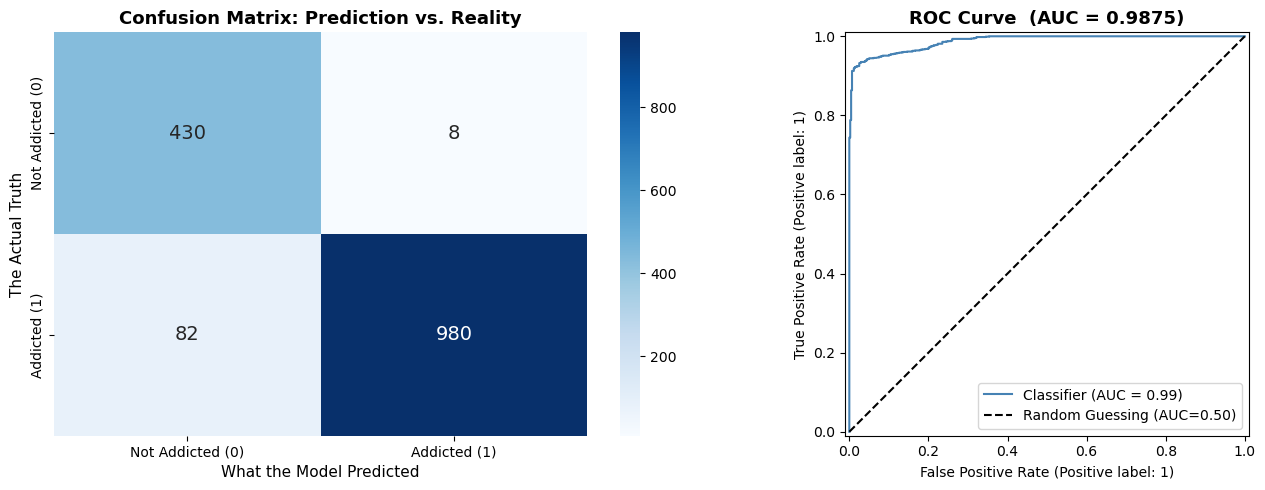

In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay,
)
import seaborn as sns
import matplotlib.pyplot as plt

# ── Generate predictions ──────────────────────────────────────────────────────
y_pred      = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# ── Classification metrics ────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("=" * 65)
print("  CONFUSION MATRIX BREAKDOWN")
print("=" * 65)
print(f"  True Positives  (TP) — Addicted users correctly caught   : {tp:>5,}")
print(f"  True Negatives  (TN) — Safe users correctly cleared      : {tn:>5,}")
print(f"  False Positives (FP) — Safe users wrongly flagged        : {fp:>5,}")
print(f"  False Negatives (FN) — Addicted users the model missed   : {fn:>5,}")

print("\n" + "=" * 65)
print("  CLASSIFICATION METRICS")
print("=" * 65)
print(f"  Accuracy  : {accuracy:.4f}  — {accuracy*100:.1f}% of all predictions were correct")
print(f"  Precision : {precision:.4f}  — when it flags addiction, it is right {precision*100:.1f}% of the time")
print(f"  Recall    : {recall:.4f}  — it caught {recall*100:.1f}% of all truly addicted users")
print(f"  F1 Score  : {f1:.4f}  — balanced measure of precision and recall")
print(f"  ROC-AUC   : {roc_auc:.4f}  — class-separation ability across all thresholds")

print("\n" + "=" * 65)
print("  FULL CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, y_pred,
      target_names=['Not Addicted (0)', 'Addicted (1)']))

# ── Visual: Confusion Matrix ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Addicted (0)', 'Addicted (1)'],
            yticklabels=['Not Addicted (0)', 'Addicted (1)'],
            annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix: Prediction vs. Reality',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('What the Model Predicted', fontsize=11)
axes[0].set_ylabel('The Actual Truth', fontsize=11)

# ── Visual: ROC Curve ─────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1],
                                  color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC=0.50)')
axes[1].set_title(f'ROC Curve  (AUC = {roc_auc:.4f})',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## Step 10: Feature Importance

Knowing that a model is accurate is useful. Understanding **why** it makes its decisions is what turns a black box into an actionable tool — essential when presenting findings to stakeholders or a panel.

A Random Forest measures feature importance by tracking, across every split in every tree, how much that split reduced **Gini impurity** (the degree of disorder in a node). Features that consistently produce the cleanest splits receive the highest importance scores. Averaging across all trees in the forest gives a stable, interpretable ranking.

The chart below directly answers: **"Which behaviors are the strongest predictors of smartphone addiction in this dataset?"**


  FEATURE IMPORTANCE RANKING
  weekend_screen_time            0.2377  ███████████████████████
  total_usage                    0.2377  ███████████████████████
  daily_screen_time_hours        0.2190  █████████████████████
  social_media_hours             0.2162  █████████████████████
  risk_ratio                     0.0685  ██████
  weekend_spike                  0.0186  █
  sleep_ratio                    0.0021  
  habit_intensity                0.0002  


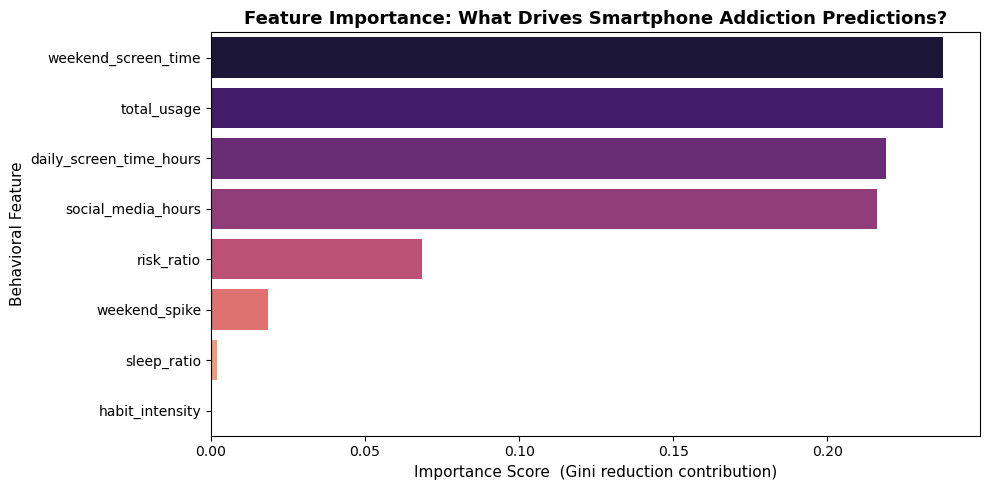


  Interpretation:
  Features at the top are the behaviors the model relies on most
  heavily when deciding whether a user is addicted. Features at
  the bottom contribute relatively little — if any score very low,
  removing them in a second iteration would clean the model further.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances   = best_model.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
    .reset_index(drop=True)
)

print("=" * 55)
print("  FEATURE IMPORTANCE RANKING")
print("=" * 55)
for _, row in importance_df.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<30} {row['Importance']:.4f}  {bar}")

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance: What Drives Smartphone Addiction Predictions?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score  (Gini reduction contribution)', fontsize=11)
plt.ylabel('Behavioral Feature', fontsize=11)
plt.tight_layout()
plt.show()

print()
print("  Interpretation:")
print("  Features at the top are the behaviors the model relies on most")
print("  heavily when deciding whether a user is addicted. Features at")
print("  the bottom contribute relatively little — if any score very low,")
print("  removing them in a second iteration would clean the model further.")


## Step 11: Validation Curve — Bias-Variance Tradeoff

The Validation Curve diagnoses one of the most fundamental challenges in machine learning: the **bias-variance tradeoff**.

- **High Bias (Underfitting):** When `max_depth` is very small, the model is too simple. Both training accuracy and cross-validation accuracy are low — the model has not learned enough from the data.
- **High Variance (Overfitting):** When `max_depth` is very large, the model memorizes training data. Training accuracy approaches 100 %, but the gap between training and cross-validation accuracy widens dramatically — the model fails on new data.
- **Sweet Spot:** The ideal `max_depth` is where cross-validation accuracy peaks before the gap starts to grow. This is where the model has learned real, generalizable patterns without memorizing noise.

The vertical dashed red line marks the `max_depth` chosen by GridSearchCV. If it sits at or near the peak of the cross-validation curve, it confirms that our tuning process correctly identified the optimal complexity.


  STEP 11: VALIDATION CURVE — BIAS VS. VARIANCE TRADEOFF

  We train a Random Forest at each depth from 1 to 5,
  using 5-fold cross-validation at each step (25 fits total).
  This shows exactly how model complexity affects learning.

  Calculating... this may take a minute.
  Done!

----------------------------------------------------------
  Depth       Train Acc       CV Acc        Gap  Verdict
----------------------------------------------------------
  1              0.8594       0.8575     0.0019  Good fit
  2              0.9265       0.9248     0.0017  Good fit
  3              0.9393       0.9372     0.0021  Good fit
  4              0.9395       0.9360     0.0035  Good fit
  5              0.9399       0.9362     0.0038  Good fit
----------------------------------------------------------

  Peak CV Accuracy : 0.9372  at max_depth = 3
  GridSearchCV chose : max_depth = 3
  ✔  Matches the peak CV depth exactly — tuning was optimal.


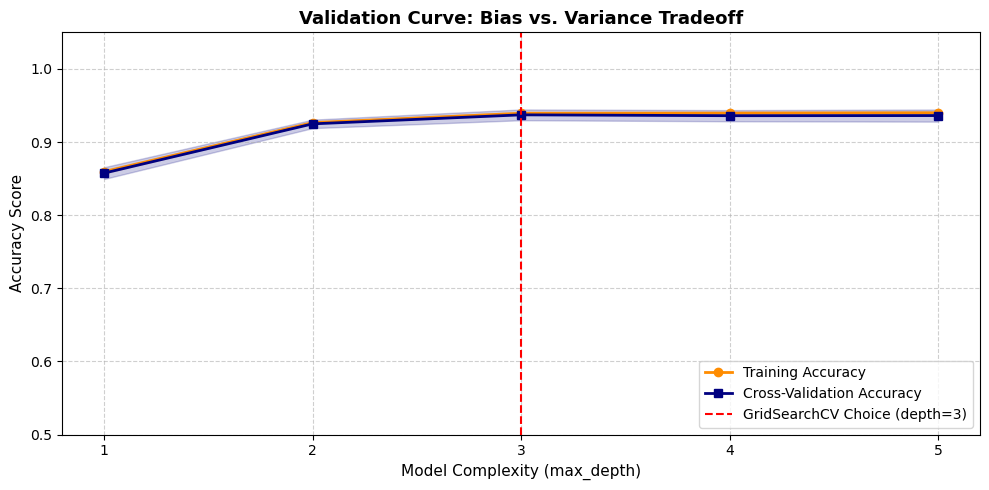


  FINAL MODEL FITNESS SUMMARY
  Training Accuracy : 0.9385  (93.85%)
  Test Accuracy     : 0.9400  (94.00%)
  Gap               : -0.0015  (-0.15%)

  Verdict: ✔  WELL-FITTED
  The small gap means the model generalizes well — it learned
  real patterns rather than memorizing the training data.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

param_range = np.arange(1, 6)  # Depths 1 through 5

print("=" * 60)
print("  STEP 11: VALIDATION CURVE — BIAS VS. VARIANCE TRADEOFF")
print("=" * 60)
print()
print("  We train a Random Forest at each depth from 1 to 5,")
print("  using 5-fold cross-validation at each step (25 fits total).")
print("  This shows exactly how model complexity affects learning.")
print()
print("  Calculating... this may take a minute.")

train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_train_scaled, y_train,
    param_name  = "max_depth",
    param_range = param_range,
    cv          = 5,
    scoring     = "accuracy",
    n_jobs      = -1,
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
test_mean  = np.mean(test_scores,  axis=1)
test_std   = np.std(test_scores,   axis=1)

print("  Done!\n")
print("-" * 58)
print(f"  {'Depth':<8} {'Train Acc':>12} {'CV Acc':>12} {'Gap':>10}  Verdict")
print("-" * 58)
for i, depth in enumerate(param_range):
    gap     = train_mean[i] - test_mean[i]
    verdict = "Underfitting" if test_mean[i] < 0.80 else ("Overfitting" if gap > 0.07 else "Good fit")
    print(f"  {depth:<8} {train_mean[i]:>12.4f} {test_mean[i]:>12.4f} {gap:>10.4f}  {verdict}")
print("-" * 58)

best_cv_depth = param_range[np.argmax(test_mean)]
best_cv_acc   = np.max(test_mean)
print(f"\n  Peak CV Accuracy : {best_cv_acc:.4f}  at max_depth = {best_cv_depth}")

best_depth = grid_search.best_params_.get('max_depth', 5)
if best_depth is None or best_depth > 5:
    best_depth = 5
print(f"  GridSearchCV chose : max_depth = {best_depth}")

if best_depth == best_cv_depth:
    print("  ✔  Matches the peak CV depth exactly — tuning was optimal.")
elif abs(best_depth - best_cv_depth) <= 1:
    print(f"  ≈  Very close to the peak CV depth ({best_cv_depth}). Acceptable.")
else:
    print(f"  ⚠  Differs from peak CV depth ({best_cv_depth}). Review tuning.")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.title("Validation Curve: Bias vs. Variance Tradeoff",
          fontsize=13, fontweight='bold')
plt.xlabel("Model Complexity (max_depth)", fontsize=11)
plt.ylabel("Accuracy Score", fontsize=11)

plt.plot(param_range, train_mean, label="Training Accuracy",
         color="darkorange", marker='o', linewidth=2)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color="darkorange")

plt.plot(param_range, test_mean, label="Cross-Validation Accuracy",
         color="navy", marker='s', linewidth=2)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                 alpha=0.2, color="navy")

plt.axvline(x=best_depth, color='red', linestyle='--', linewidth=1.5,
            label=f'GridSearchCV Choice (depth={best_depth})')
plt.xticks(param_range)
plt.ylim(0.5, 1.05)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Final fitness summary ─────────────────────────────────────────────────────
train_acc = best_model.score(X_train_scaled, y_train)
test_acc  = best_model.score(X_test_scaled,  y_test)
gap       = train_acc - test_acc

print()
print("=" * 60)
print("  FINAL MODEL FITNESS SUMMARY")
print("=" * 60)
print(f"  Training Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Gap               : {gap:.4f}  ({gap*100:.2f}%)")
print()

if gap < 0.03:
    print("  Verdict: ✔  WELL-FITTED")
    print("  The small gap means the model generalizes well — it learned")
    print("  real patterns rather than memorizing the training data.")
elif gap < 0.07:
    print("  Verdict: ≈  SLIGHT OVERFITTING")
    print("  Tolerable range. Reducing max_depth slightly could close the gap.")
else:
    print("  Verdict: ✘  OVERFITTING DETECTED")
    print("  Consider reducing max_depth or increasing min_samples_split.")
print("=" * 60)


## Step 12: Saving the Model

Once we are satisfied with performance, we **serialize** the model to disk — converting the trained Python object into a file that can be stored, shared, and reloaded later without retraining.

We use `joblib`, which is the recommended library for scikit-learn models because it handles large NumPy arrays (like the many trees inside a Random Forest) far more efficiently than Python's built-in `pickle`.

**We save two files — both are required:**

| File | Contents | Why it is mandatory |
|---|---|---|
| `smartphone_addiction_model.pkl` | The trained Random Forest | The model itself — contains all learned decision rules |
| `scaler_v1.pkl` | The fitted StandardScaler | Any new data submitted for prediction must pass through the **exact same scaling** the training data used. Without this file, predictions on new data are meaningless. |

We verify the saves by reloading both files and running sample predictions to confirm they produce correct output.


In [24]:
import joblib
joblib.dump(best_model, 'smartphone_addiction_model.pkl')
joblib.dump(scaler,     'scaler_v1.pkl')

print("=" * 50)
print("  FILES SAVED")
print("=" * 50)
print("  smartphone_addiction_model.pkl — trained Random Forest")
print("  scaler_v1.pkl                  — fitted StandardScaler")
print()

# ── Verify: reload both files and run sample predictions ─────────────────────
loaded_model  = joblib.load('smartphone_addiction_model.pkl')
loaded_scaler = joblib.load('scaler_v1.pkl')

sample_X     = X_test.iloc[:5]
sample_scaled = loaded_scaler.transform(sample_X)
sample_preds  = loaded_model.predict(sample_scaled)
sample_proba  = loaded_model.predict_proba(sample_scaled)[:, 1]

print("=" * 65)
print("  VERIFICATION — SAMPLE PREDICTIONS FROM RELOADED MODEL")
print("=" * 65)
print(f"  {'Row':<5} {'Prediction':<15} {'Probability (Addicted)':>22}")
print("-" * 65)
for i, (pred, prob) in enumerate(zip(sample_preds, sample_proba)):
    label = "Addicted (1)" if pred == 1 else "Not Addicted (0)"
    print(f"  {i:<5} {label:<15} {prob:>22.4f}")

print()
print("  Both files loaded and verified successfully.")
print("  The model is ready for deployment.")


  FILES SAVED
  smartphone_addiction_model.pkl — trained Random Forest
  scaler_v1.pkl                  — fitted StandardScaler

  VERIFICATION — SAMPLE PREDICTIONS FROM RELOADED MODEL
  Row   Prediction      Probability (Addicted)
-----------------------------------------------------------------
  0     Not Addicted (0)                 0.0879
  1     Addicted (1)                    0.9833
  2     Not Addicted (0)                 0.0752
  3     Addicted (1)                    0.9853
  4     Addicted (1)                    0.9543

  Both files loaded and verified successfully.
  The model is ready for deployment.
